 ## 1. Import the Libraries 

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

## 2. Load the pre-processed CSV files

After the data has pre-processed using R, we split the data into train and test and exported these data files into current working directory. Load the train and test data files in python and implement the models.

In [3]:
# Read the CSV file into a DataFrame
# Load the train data
df = pd.read_csv("train_df.csv")

# Display the first few rows
print(df.head())

   housing_statusBA  fraud_ratio  credit_risk_score  proposed_credit_limit  \
0               1.0     0.066061               79.0               5.303305   
1               0.0     0.036388              184.0               7.313887   
2               0.0     0.003152              167.0               6.216606   
3               0.0     0.004658              167.0               6.216606   
4               0.0     0.006915               84.0               5.303305   

   age_device_interaction50.59_windows  age_device_interaction60.69_windows  \
0                                  0.0                                  0.0   
1                                  1.0                                  0.0   
2                                  0.0                                  0.0   
3                                  0.0                                  0.0   
4                                  0.0                                  0.0   

   keep_alive_session  income  date_of_birth_distinct_em

In [4]:
# Display first few rows of train data
print('Train Data:')
df.head()

Train Data:


,housing_statusBA,fraud_ratio,credit_risk_score,proposed_credit_limit,age_device_interaction50.59_windows,age_device_interaction60.69_windows,keep_alive_session,income,date_of_birth_distinct_emails_4w,age_velocity_ratio,...,employment_statusCA,foreign_request,employment_statusCB,age_device_interaction40.49_linux,age_device_interaction80.89_windows,session_intensity,velocity_growth,normalized_velocity,banking_activity,fraud_bool
0,1.0,0.066061,79.0,5.303305,0.0,0.0,1.0,0.9,5.0,49.031750,...,1.0,0.0,0.0,0.0,0.0,0.001086,0.708508,1.131615,18.000000,0
1,0.0,0.036388,184.0,7.313887,1.0,0.0,0.0,0.9,13.0,97.447401,...,1.0,0.0,0.0,0.0,0.0,0.000873,2.347743,0.313786,4.000000,1
2,0.0,0.003152,167.0,6.216606,0.0,0.0,0.0,0.6,23.0,297.161266,...,1.0,0.0,0.0,0.0,0.0,0.000535,0.804205,1.535817,1.000000,0
3,0.0,0.004658,167.0,6.216606,0.0,0.0,1.0,0.8,8.0,166.380443,...,0.0,0.0,0.0,0.0,0.0,0.001369,0.590650,1.788666,-1.000000,0
4,0.0,0.006915,84.0,5.303305,0.0,0.0,0.0,0.9,7.0,155.722610,...,1.0,0.0,0.0,0.0,0.0,0.001200,0.641241,2.007785,119.133333,0


In [5]:
# Load test dataset
testData = pd.read_csv("test_df.csv")
print('Test Data:')
testData.head() #display first few rows

Test Data:


,housing_statusBA,fraud_ratio,credit_risk_score,proposed_credit_limit,age_device_interaction50.59_windows,age_device_interaction60.69_windows,keep_alive_session,income,date_of_birth_distinct_emails_4w,age_velocity_ratio,...,employment_statusCA,foreign_request,employment_statusCB,age_device_interaction40.49_linux,age_device_interaction80.89_windows,fraud_bool,session_intensity,velocity_growth,normalized_velocity,banking_activity
0,0,0.011578,250,6.216606,0,0,0,0.9,5,42.208919,...,1,0,0,0,0,0,0.000873,0.588845,1.013525,0.290323
1,0,0.002302,-35,5.303305,0,0,1,0.2,9,140.239214,...,0,0,0,0,0,0,0.002844,1.156754,0.691899,-1.000000
2,0,0.004188,190,5.303305,0,0,1,0.6,6,131.408613,...,1,0,0,0,0,0,0.002410,0.681651,1.386264,46.133333
3,1,0.006915,295,5.303305,0,0,0,0.3,4,70.718256,...,1,0,0,0,0,0,0.001490,1.146684,0.569256,0.640000
4,0,0.002302,-57,5.303305,0,0,1,0.1,8,229.874597,...,0,0,0,0,0,0,0.001196,0.752698,1.427808,-1.000000


## 3. Analysis of the train and test data

In [6]:
# Check column consistency
print("Train Data Columns:")
print(df.columns)

print("Test Data Columns:")
print(testData.columns)

# Verify dimensions
print("Train Data Dimensions:", df.shape)
print("Test Data Dimensions:", testData.shape)

Train Data Columns:
Index(['housing_statusBA', 'fraud_ratio', 'credit_risk_score',
       'proposed_credit_limit', 'age_device_interaction50.59_windows',
       'age_device_interaction60.69_windows', 'keep_alive_session', 'income',
       'date_of_birth_distinct_emails_4w', 'age_velocity_ratio',
       'age_device_interaction40.49_windows', 'name_email_similarity',
       'housing_statusBC', 'device_distinct_emails_8w', 'has_other_cards',
       'phone_home_valid', 'device_activity_ratio', 'housing_statusBE',
       'payment_typeAC', 'housing_statusBB', 'email_is_free',
       'prev_address_months_count', 'age_device_interaction70.79_windows',
       'employment_statusCC', 'intended_balcon_amount',
       'age_device_interaction20.29_other',
       'age_device_interaction20.29_linux',
       'age_device_interaction30.39_windows',
       'age_device_interaction30.39_linux',
       'age_device_interaction30.39_other', 'address_stability',
       'employment_statusCF', 'employment_statusC

In [7]:
# Split features and target for training and testing datasets
X_train = df.drop(columns=["fraud_bool"])  # Features
y_train = df["fraud_bool"]  # Target variable

X_test = testData.drop(columns=['fraud_bool'])
y_test = testData['fraud_bool']

## 4. Machine learning Algorithms Implementation 
### 4.1 Decision Trees

Decision Tree is implemented initially to find the best parameters and these parameters are used in the classifier.

In [15]:
# Implement Decision tree
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# To find best parameters
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [10, 12, 14, 16],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5)
grid_search.fit(X_train, y_train)

print("Best parameters found: ", grid_search.best_params_)

Best parameters found:  {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}


In [27]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier with the optimal parameters
dt_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=10,
    min_samples_leaf=1,
    min_samples_split=5,
    random_state=42
)

# Train the model
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_split=5,
                       random_state=42)

In [28]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Predict on the test set
y_pred = dt_model.predict(X_test)

# Evaluate the model
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
# Calculate Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.75      0.86    202133
           1       0.04      0.76      0.08      2878

    accuracy                           0.75    205011
   macro avg       0.52      0.75      0.47    205011
weighted avg       0.98      0.75      0.85    205011

Confusion Matrix:
 [[151896  50237]
 [   704   2174]]
Accuracy: 0.7515206501114574


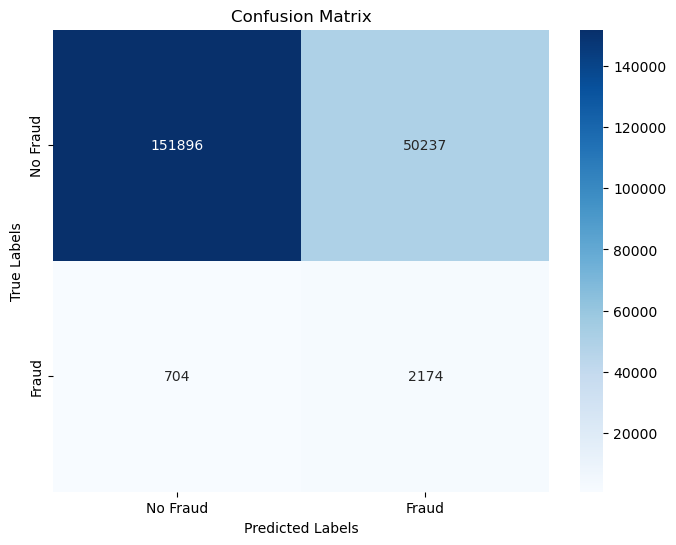

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Create a heatmap for visualization
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Fraud', 'Fraud'], yticklabels=['No Fraud', 'Fraud'])

# Add labels, title, and improve layout
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

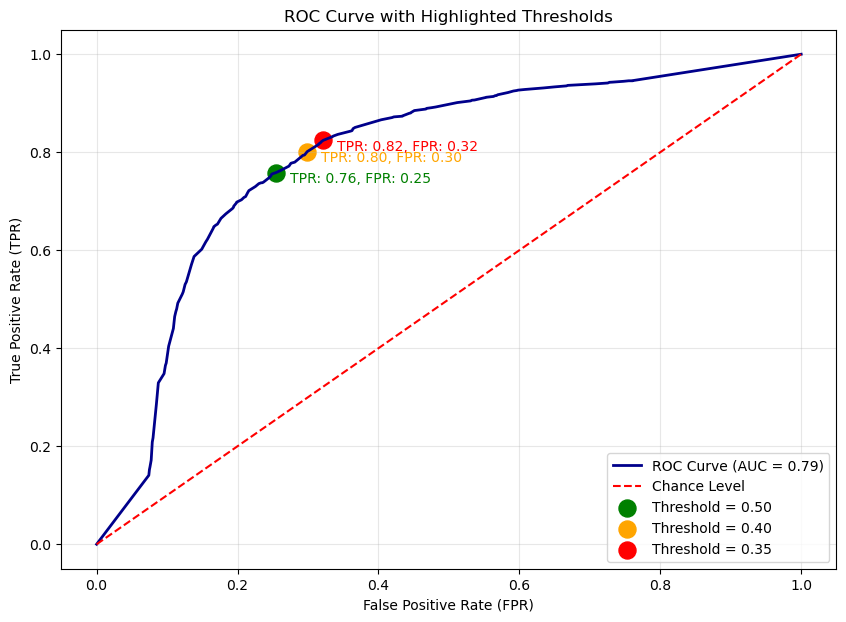

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate probabilities and ROC metrics
y_probabilities = dt_model.predict_proba(X_test)[:, 1]
false_positive_rate, true_positive_rate, roc_thresholds = roc_curve(y_test, y_probabilities)
roc_auc_value = roc_auc_score(y_test, y_probabilities)

# Define threshold points to annotate
threshold_points = [0.5, 0.4, 0.35]
highlight_indices = [np.abs(roc_thresholds - t).argmin() for t in threshold_points]

# Plot the ROC curve
plt.figure(figsize=(10, 7))
plt.plot(false_positive_rate, true_positive_rate, label=f'ROC Curve (AUC = {roc_auc_value:.2f})', color='darkblue', lw=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Chance Level')

# Highlight points at specified thresholds
colors = ['green', 'orange', 'red']
for idx, threshold, color in zip(highlight_indices, threshold_points, colors):
    plt.scatter(false_positive_rate[idx], true_positive_rate[idx], color=color, s=150, label=f'Threshold = {threshold:.2f}')
    plt.annotate(f"TPR: {true_positive_rate[idx]:.2f}, FPR: {false_positive_rate[idx]:.2f}",
                 (false_positive_rate[idx] + 0.02, true_positive_rate[idx] - 0.02),
                 fontsize=10, color=color)

# Add grid, labels, and legend
plt.title('ROC Curve with Highlighted Thresholds')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

### Decison Tree implementation after adding ccp_alpha

In [58]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier with the optimal parameters
dt_model_tuned = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=10,
    min_samples_leaf=1,
    min_samples_split=5,
    ccp_alpha=0.1,
    class_weight='balanced',
    random_state=42
)

# Train the model
dt_model_tuned.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.1, class_weight='balanced',
                       criterion='entropy', max_depth=10, min_samples_split=5,
                       random_state=42)

In [59]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,f1_score

# Predict on the test set
y_pred = dt_model_tuned.predict(X_test)

# Evaluate the model
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
# Calculate Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.81      0.89    202133
           1       0.04      0.62      0.08      2878

    accuracy                           0.81    205011
   macro avg       0.52      0.72      0.49    205011
weighted avg       0.98      0.81      0.88    205011

Confusion Matrix:
 [[164019  38114]
 [  1092   1786]]
Accuracy: 0.8087614810912586


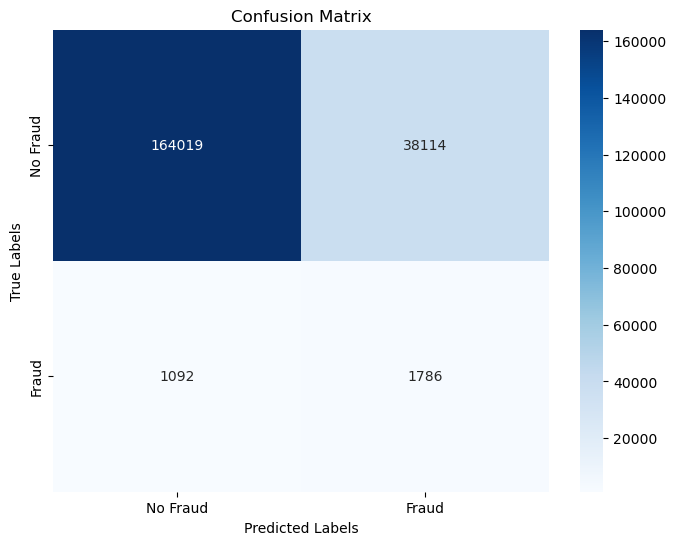

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Create a heatmap for visualization
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Fraud', 'Fraud'], yticklabels=['No Fraud', 'Fraud'])

# Add labels, title, and improve layout
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

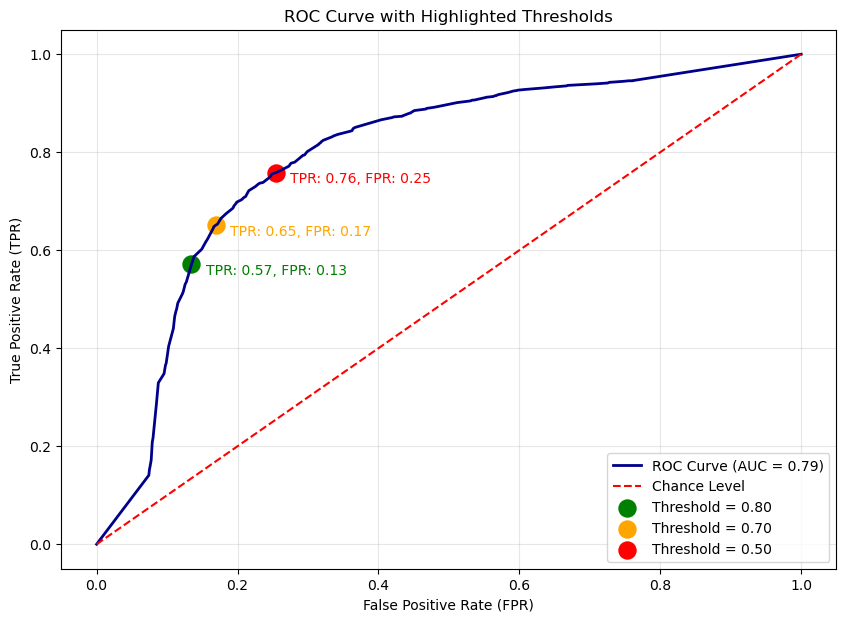

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate probabilities and ROC metrics
y_probabilities = dt_model.predict_proba(X_test)[:, 1]
false_positive_rate, true_positive_rate, roc_thresholds = roc_curve(y_test, y_probabilities)
roc_auc_value = roc_auc_score(y_test, y_probabilities)

# Define threshold points to annotate
threshold_points = [0.8, 0.7, 0.5]
highlight_indices = [np.abs(roc_thresholds - t).argmin() for t in threshold_points]

# Plot the ROC curve
plt.figure(figsize=(10, 7))
plt.plot(false_positive_rate, true_positive_rate, label=f'ROC Curve (AUC = {roc_auc_value:.2f})', color='darkblue', lw=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Chance Level')

# Highlight points at specified thresholds
colors = ['green', 'orange', 'red']
for idx, threshold, color in zip(highlight_indices, threshold_points, colors):
    plt.scatter(false_positive_rate[idx], true_positive_rate[idx], color=color, s=150, label=f'Threshold = {threshold:.2f}')
    plt.annotate(f"TPR: {true_positive_rate[idx]:.2f}, FPR: {false_positive_rate[idx]:.2f}",
                 (false_positive_rate[idx] + 0.02, true_positive_rate[idx] - 0.02),
                 fontsize=10, color=color)

# Add grid, labels, and legend
plt.title('ROC Curve with Highlighted Thresholds')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

### 4.2 Logistic Regression 

In [41]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression Model
lr_model = LogisticRegression(random_state=42,solver='liblinear', max_iter=100)
lr_model.fit(X_train, y_train)

# Predictions
y_pred = lr_model.predict(X_test)
y_pred_prob = lr_model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class

# Evaluation Metrics
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_prob))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.79      0.88    202133
           1       0.05      0.80      0.10      2878

    accuracy                           0.79    205011
   macro avg       0.52      0.79      0.49    205011
weighted avg       0.98      0.79      0.87    205011

Confusion Matrix:
 [[159727  42406]
 [   579   2299]]
Accuracy: 0.7903283238460376
ROC-AUC Score: 0.8740500646085523


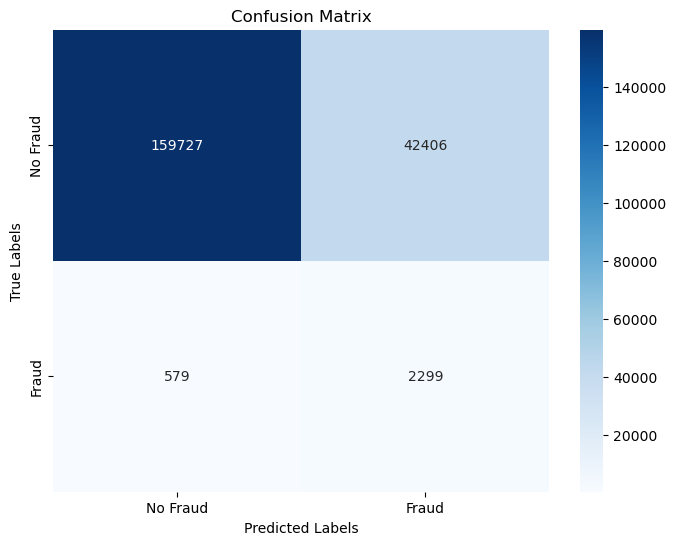

In [42]:
# Generate the confusion matrix heatmap
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Fraud', 'Fraud'], yticklabels=['No Fraud', 'Fraud'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

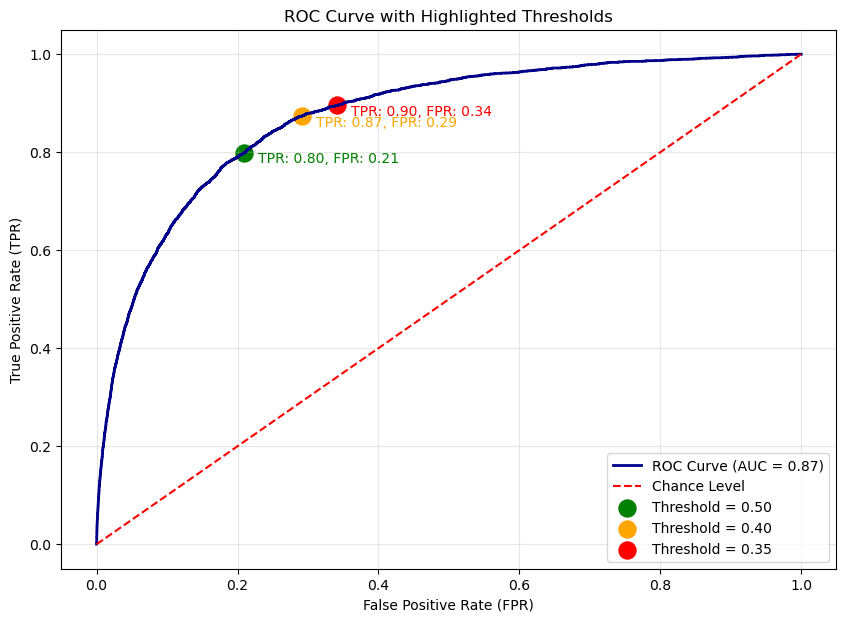

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate probabilities and ROC metrics
y_probabilities = lr_model.predict_proba(X_test)[:, 1]
false_positive_rate, true_positive_rate, roc_thresholds = roc_curve(y_test, y_probabilities)
roc_auc_value = roc_auc_score(y_test, y_probabilities)

# Define threshold points to annotate
threshold_points = [0.5, 0.4, 0.35]
highlight_indices = [np.abs(roc_thresholds - t).argmin() for t in threshold_points]

# Plot the ROC curve
plt.figure(figsize=(10, 7))
plt.plot(false_positive_rate, true_positive_rate, label=f'ROC Curve (AUC = {roc_auc_value:.2f})', color='darkblue', lw=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Chance Level')

# Highlight points at specified thresholds
colors = ['green', 'orange', 'red']
for idx, threshold, color in zip(highlight_indices, threshold_points, colors):
    plt.scatter(false_positive_rate[idx], true_positive_rate[idx], color=color, s=150, label=f'Threshold = {threshold:.2f}')
    plt.annotate(f"TPR: {true_positive_rate[idx]:.2f}, FPR: {false_positive_rate[idx]:.2f}",
                 (false_positive_rate[idx] + 0.02, true_positive_rate[idx] - 0.02),
                 fontsize=10, color=color)

# Add grid, labels, and legend
plt.title('ROC Curve with Highlighted Thresholds')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

### Logistic Regression after hyper-parameter Tuning

In [46]:
# Implement Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the Logistic Regression model with the best parameters
log_reg_tuned = LogisticRegression(
    penalty='l1',
    C=100,
    solver='liblinear',
    random_state=42,
    max_iter=100
)

# Train the model
log_reg_tuned.fit(X_train, y_train)

LogisticRegression(C=100, penalty='l1', random_state=42, solver='liblinear')

In [47]:
# Predict on the test set
y_pred = log_reg_tuned.predict(X_test)

# Evaluate the model
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.80      0.89    202133
           1       0.05      0.80      0.10      2878

    accuracy                           0.80    205011
   macro avg       0.52      0.80      0.49    205011
weighted avg       0.98      0.80      0.88    205011

Confusion Matrix:
 [[161467  40666]
 [   585   2293]]
Accuracy: 0.7987864065830614


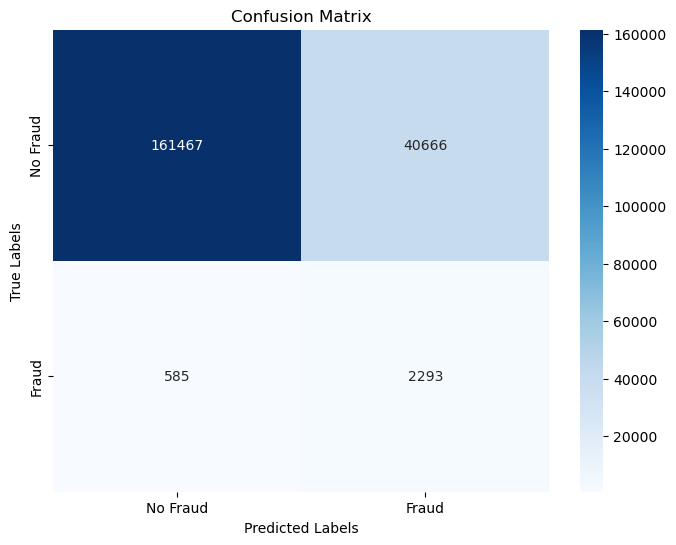

In [48]:
# Generate the confusion matrix heatmap
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Fraud', 'Fraud'], yticklabels=['No Fraud', 'Fraud'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

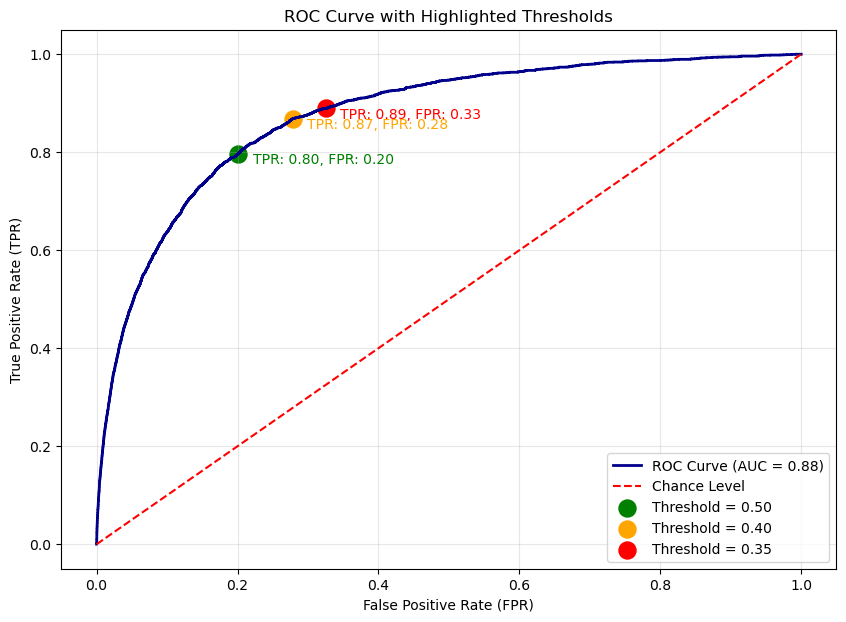

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate probabilities and ROC metrics
y_probabilities = log_reg_tuned.predict_proba(X_test)[:, 1]
false_positive_rate, true_positive_rate, roc_thresholds = roc_curve(y_test, y_probabilities)
roc_auc_value = roc_auc_score(y_test, y_probabilities)

# Define threshold points to annotate
threshold_points = [0.5, 0.4, 0.35]
highlight_indices = [np.abs(roc_thresholds - t).argmin() for t in threshold_points]

# Plot the ROC curve
plt.figure(figsize=(10, 7))
plt.plot(false_positive_rate, true_positive_rate, label=f'ROC Curve (AUC = {roc_auc_value:.2f})', color='darkblue', lw=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Chance Level')

# Highlight points at specified thresholds
colors = ['green', 'orange', 'red']
for idx, threshold, color in zip(highlight_indices, threshold_points, colors):
    plt.scatter(false_positive_rate[idx], true_positive_rate[idx], color=color, s=150, label=f'Threshold = {threshold:.2f}')
    plt.annotate(f"TPR: {true_positive_rate[idx]:.2f}, FPR: {false_positive_rate[idx]:.2f}",
                 (false_positive_rate[idx] + 0.02, true_positive_rate[idx] - 0.02),
                 fontsize=10, color=color)

# Add grid, labels, and legend
plt.title('ROC Curve with Highlighted Thresholds')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()